# GCSE and A-level Value Added in Mathematics — a Bayesian model

We want to understand how much of a school's value-added effect at KS4 (GCSE) carries through to KS5 (A-level), starting with Mathematics before generalising to other subjects.

Both value-added measures published by the DfE are noisy point estimates — each comes with a 95% confidence interval that varies school to school (smaller cohorts give wider intervals). Regressing one point estimate on the other and ignoring that noise would understate the true uncertainty in the relationship and can bias the estimated slope towards zero (attenuation bias). Instead we build a Bayesian **errors-in-variables (measurement-error) regression**: each school's *true* GCSE and A-level maths value-added are latent quantities, and the published confidence intervals define the observation noise around them.

We follow the standard Bayesian workflow: prior predictive check -> fit -> diagnostics -> posterior predictive check -> interpret.

In [1]:
import arviz as az
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm

%config InlineBackend.figure_format = 'retina'
RANDOM_SEED = 8927
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-darkgrid")

print(f"Running on PyMC v{pm.__version__}")

Running on PyMC v6.3.1


## Data

`data/maths-value-add-errors.csv` has one row per school (`URN`) with:
- the A-level Maths value-added score and its 95% confidence interval, and
- the GCSE Maths Progress 8 measure (`P8MEAMAT`) and its 95% confidence interval.

We convert each interval to an implied standard error, assuming a 95% normal confidence interval: `se = (upper - lower) / (2 * 1.96)`. We keep only schools where both the GCSE and A-level measures are present — schools with just one (e.g. no sixth form, or no GCSE cohort recorded) are out of scope for this relationship.

In [2]:
raw = pd.read_csv("data/maths-value-add-errors.csv")

df = (
    raw.rename(
        columns={
            "A-level Maths VA": "alevel_va",
            "A-level Maths VA lower": "alevel_lower",
            "A-level Maths VA upper": "alevel_upper",
            "P8MEAMAT": "gcse_va",
            "P8MEAMAT lower": "gcse_lower",
            "P8MEAMAT upper": "gcse_upper",
        }
    )
    .dropna(subset=["alevel_va", "gcse_va"])
    .reset_index(drop=True)
)

Z_95 = 1.96
df["alevel_se"] = (df["alevel_upper"] - df["alevel_lower"]) / (2 * Z_95)
df["gcse_se"] = (df["gcse_upper"] - df["gcse_lower"]) / (2 * Z_95)

print(f"{len(df)} schools with both GCSE and A-level maths value-added")
df[["alevel_va", "alevel_se", "gcse_va", "gcse_se"]].describe()

1622 schools with both GCSE and A-level maths value-added


,alevel_va,alevel_se,gcse_va,gcse_se
count,1622.000000,1622.000000,1622.000000,1622.000000
mean,-0.093397,0.263356,0.140136,0.111871
std,0.498176,0.101383,0.469802,0.022130
min,-2.170000,0.071429,-2.290000,0.071429
25%,-0.390000,0.183673,-0.150000,0.096939
50%,-0.050000,0.250000,0.130000,0.107143
75%,0.240000,0.329082,0.420000,0.119898
max,1.730000,0.502551,2.490000,0.369898


## Exploratory look

A scatter of the two point estimates, with error bars showing each school's known uncertainty, before any model is fit.

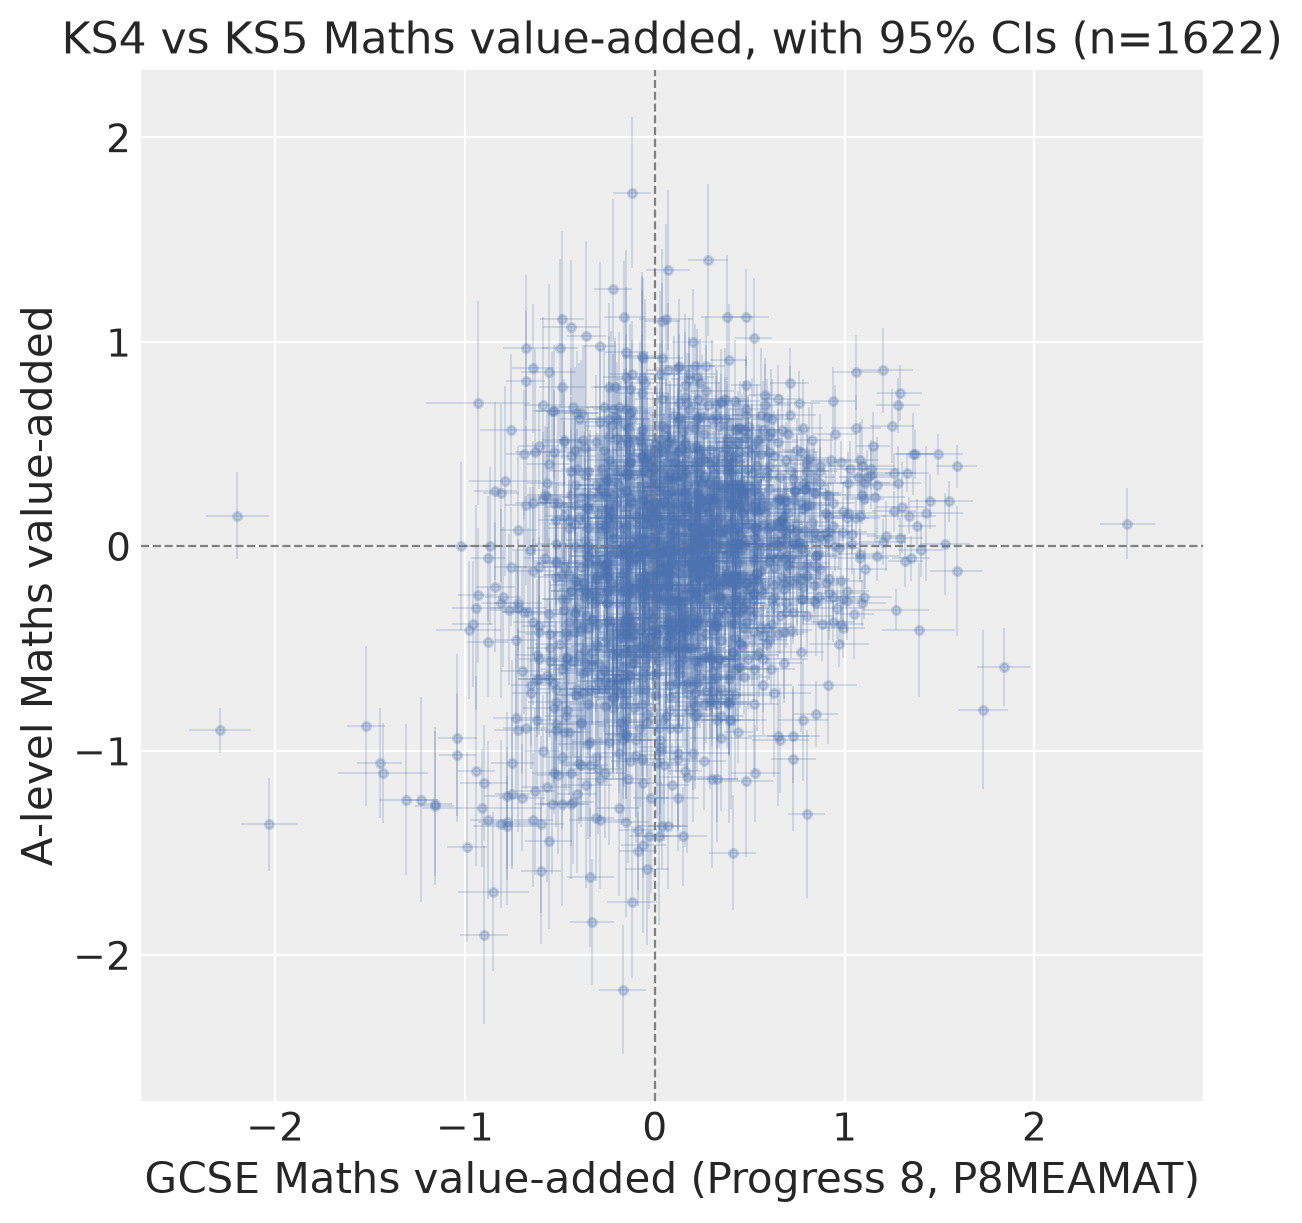

In [3]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.errorbar(
    df["gcse_va"], df["alevel_va"],
    xerr=df["gcse_se"], yerr=df["alevel_se"],
    fmt="o", color="#4C72B0", ecolor="#4C72B0",
    alpha=0.25, markersize=3, elinewidth=0.6,
)
ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
ax.axvline(0, color="grey", linewidth=0.8, linestyle="--")
ax.set_xlabel("GCSE Maths value-added (Progress 8, P8MEAMAT)")
ax.set_ylabel("A-level Maths value-added")
ax.set_title(f"KS4 vs KS5 Maths value-added, with 95% CIs (n={len(df)})")
plt.show()

## Model: Bayesian errors-in-variables regression

For each school $i$ we don't observe the *true* value-added $x_i$ (GCSE) and $y_i$ (A-level) directly — we observe noisy estimates $x_i^{obs}, y_i^{obs}$ with known standard errors $\sigma^x_i, \sigma^y_i$ derived from the published confidence intervals.

$$
\begin{aligned}
x_i &\sim \text{Normal}(\mu_x, \tau_x) \\
x_i^{obs} &\sim \text{Normal}(x_i, \sigma^x_i) \\[4pt]
y_i &= \alpha + \beta x_i + \epsilon_i, \quad \epsilon_i \sim \text{Normal}(0, \tau_y) \\
y_i^{obs} &\sim \text{Normal}(y_i, \sigma^y_i)
\end{aligned}
$$

$\beta$ is the quantity we care about: how much of a school's *true* GCSE maths value-added carries over to *true* A-level maths value-added, correcting for the fact both are noisy estimates rather than the truth. $x_i$ and $y_i$ are modelled with a non-centered parameterisation ($x_i = \mu_x + \tau_x \cdot z_i$) for better sampling geometry.

In [4]:
gcse_obs = df["gcse_va"].to_numpy()
gcse_se = df["gcse_se"].to_numpy()
alevel_obs = df["alevel_va"].to_numpy()
alevel_se = df["alevel_se"].to_numpy()
n_schools = len(df)

with pm.Model() as eiv_model:
    # true (latent) GCSE value-added per school, non-centered
    mu_x = pm.Normal("mu_x", mu=0, sigma=1)
    tau_x = pm.HalfNormal("tau_x", sigma=1)
    x_raw = pm.Normal("x_raw", mu=0, sigma=1, shape=n_schools)
    x_true = pm.Deterministic("x_true", mu_x + tau_x * x_raw)

    # structural regression: true A-level VA as a function of true GCSE VA
    alpha = pm.Normal("alpha", mu=0, sigma=1)
    beta = pm.Normal("beta", mu=0, sigma=1)
    tau_y = pm.HalfNormal("tau_y", sigma=1)
    y_raw = pm.Normal("y_raw", mu=0, sigma=1, shape=n_schools)
    y_true = pm.Deterministic("y_true", alpha + beta * x_true + tau_y * y_raw)

    # measurement model: observed VA scores are noisy versions of the truth,
    # with per-school noise fixed to the published confidence interval
    pm.Normal("gcse_obs", mu=x_true, sigma=gcse_se, observed=gcse_obs)
    pm.Normal("alevel_obs", mu=y_true, sigma=alevel_se, observed=alevel_obs)

### Prior predictive check

Before fitting, simulate observed data from the priors alone. Value-added scores are typically in roughly [-2, 2], so this checks the priors aren't putting most of their mass somewhere implausible.

Sampling: [alevel_obs, alpha, beta, gcse_obs, mu_x, tau_x, tau_y, x_raw, y_raw]


/tmp/ipykernel_10812/4193119287.py:9: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


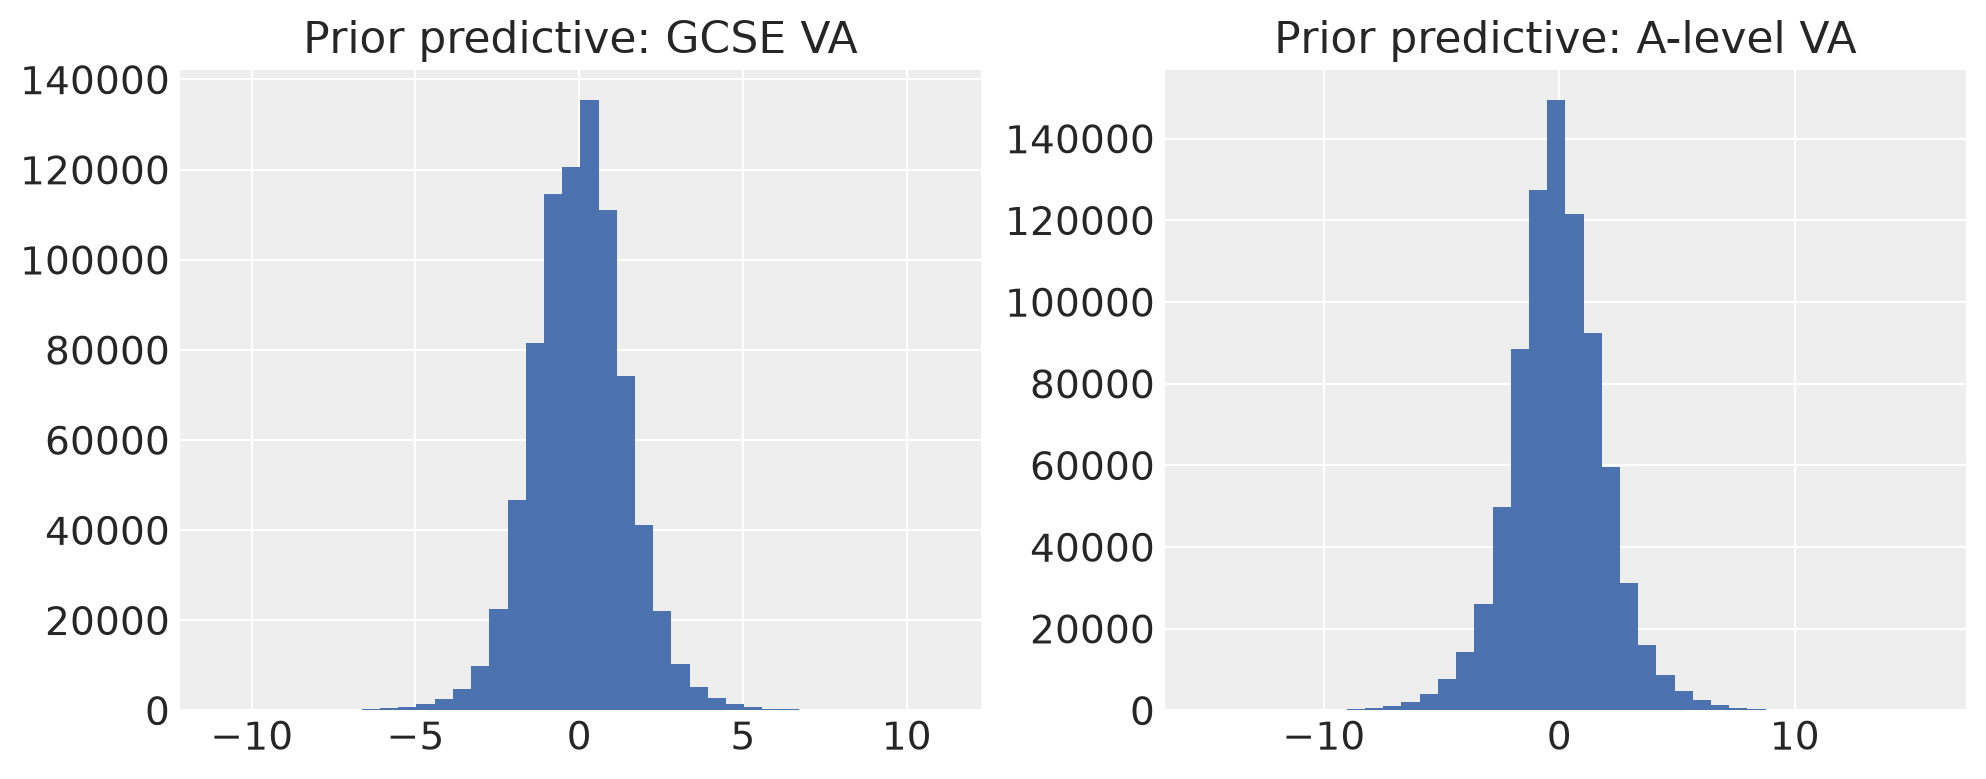

In [5]:
with eiv_model:
    prior = pm.sample_prior_predictive(draws=500, random_seed=RANDOM_SEED)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(prior.prior_predictive["gcse_obs"].to_numpy().ravel(), bins=40, color="#4C72B0")
axes[0].set_title("Prior predictive: GCSE VA")
axes[1].hist(prior.prior_predictive["alevel_obs"].to_numpy().ravel(), bins=40, color="#4C72B0")
axes[1].set_title("Prior predictive: A-level VA")
plt.tight_layout()
plt.show()

### Fit

Sample the posterior with NUTS. `target_accept=0.99` and extra tuning steps are used because the latent per-school `x_true`/`y_true` parameters create a mild funnel geometry with the population-level `tau_x`/`tau_y`.

In [6]:
with eiv_model:
    idata = pm.sample(
        draws=1000, tune=2000, chains=4, target_accept=0.99,
        random_seed=RANDOM_SEED,
    )
    ppc = pm.sample_posterior_predictive(idata, random_seed=RANDOM_SEED)

idata.update(ppc)

NUTS[nutpie]: [mu_x, tau_x, x_raw, alpha, beta, tau_y, y_raw]


Output()

Sampling: [alevel_obs, gcse_obs]


Output()

### Diagnostics

Check divergences, $\hat{R}$ and effective sample size for the population-level parameters before trusting the posterior.

In [7]:
n_divergent = int(idata.sample_stats["diverging"].sum())
print(f"Divergences: {n_divergent}")

az.summary(idata, var_names=["mu_x", "tau_x", "alpha", "beta", "tau_y"], round_to=3)

Divergences: 0


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu_x,0.139,0.011,0.121,0.156,156.604,296.789,1.014,0.001,0.0
tau_x,0.452,0.008,0.439,0.465,326.316,754.127,1.007,0.000,0.0
alpha,-0.125,0.012,-0.145,-0.106,1038.921,1335.857,1.002,0.000,0.0
beta,0.282,0.025,0.242,0.324,522.915,925.906,1.011,0.001,0.0
tau_y,0.357,0.010,0.342,0.374,1149.707,1730.208,1.002,0.000,0.0


/tmp/ipykernel_10812/1585683059.py:2: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


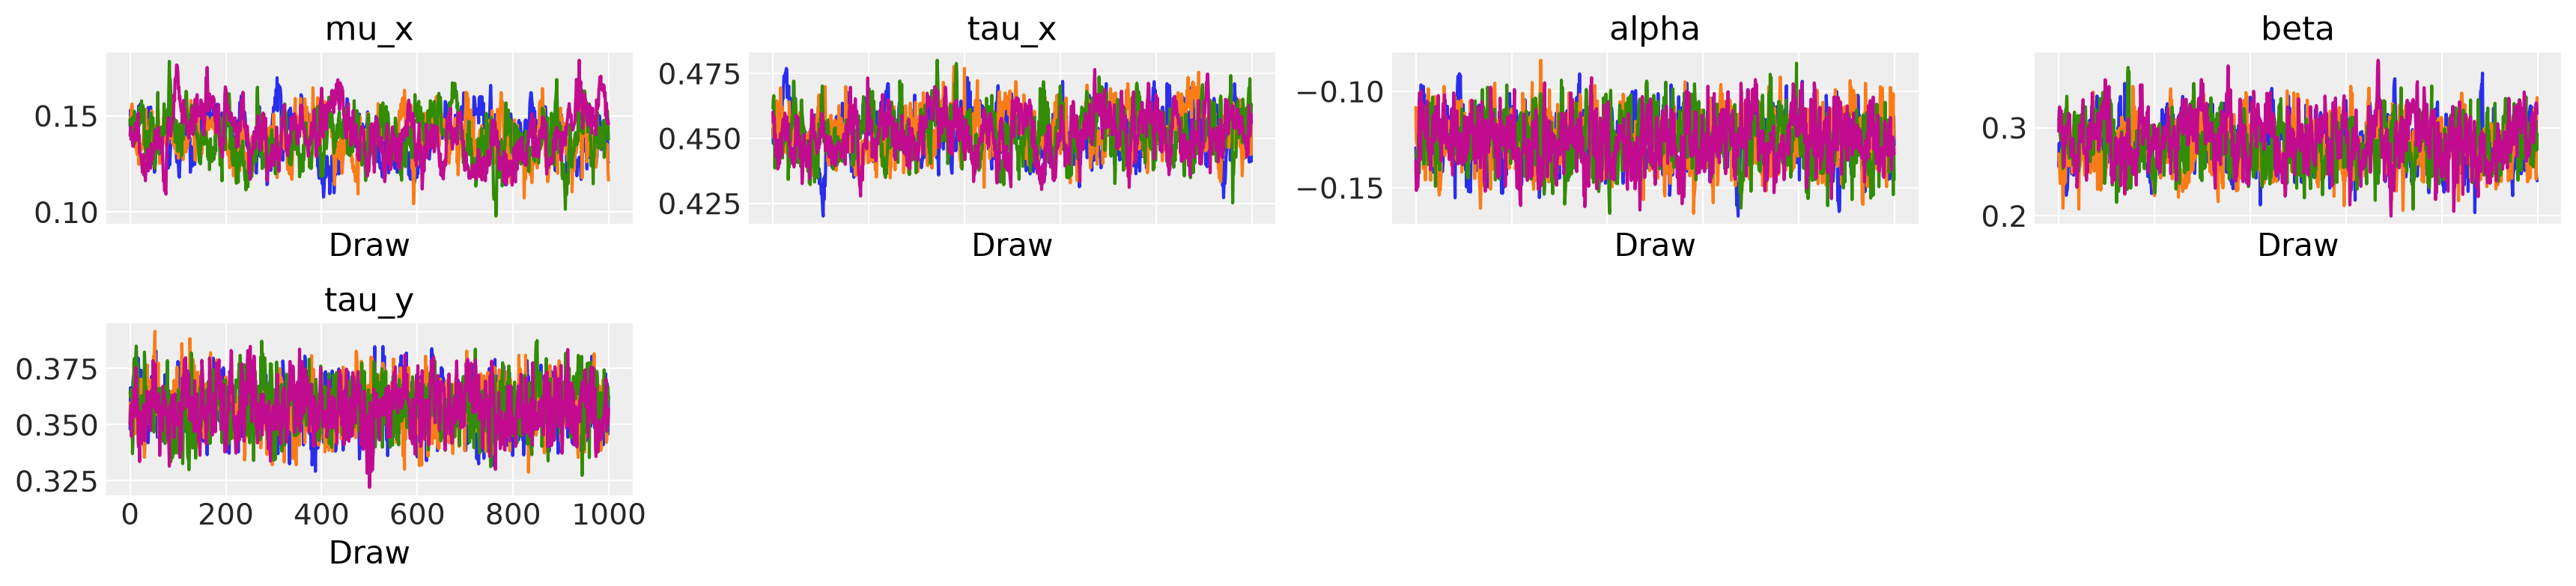

In [8]:
az.plot_trace(idata, var_names=["mu_x", "tau_x", "alpha", "beta", "tau_y"])
plt.tight_layout()

### Posterior of $\beta$

The slope relating true GCSE maths value-added to true A-level maths value-added.

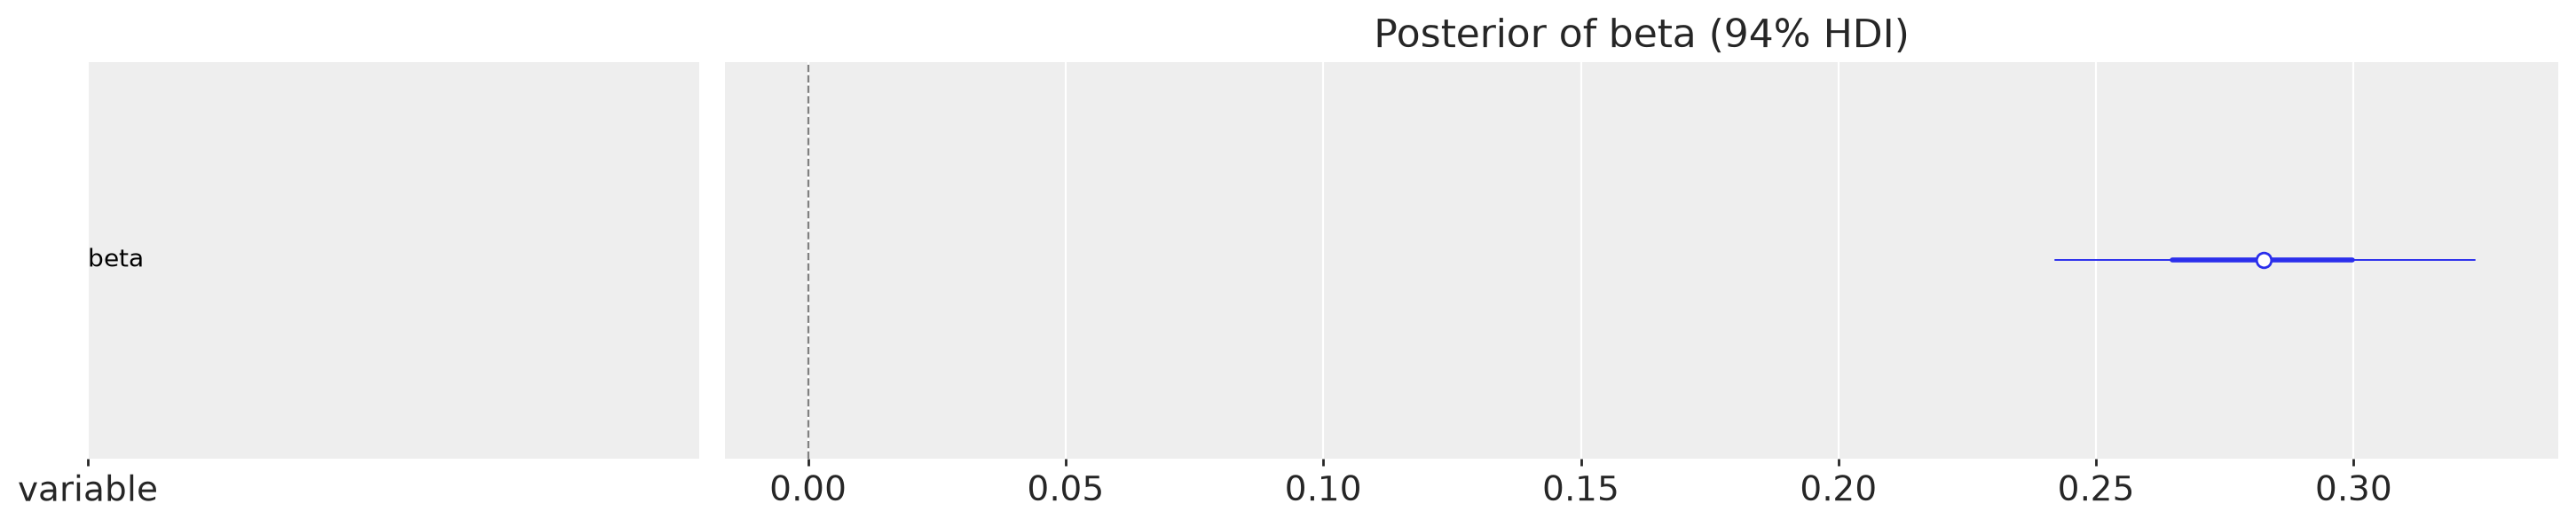

In [9]:
az.plot_forest(idata, var_names=["beta"], combined=True)
plt.axvline(0, color="grey", linewidth=0.8, linestyle="--")
plt.title("Posterior of beta (94% HDI)")
plt.show()

### Posterior predictive check

Compare the observed distribution of each measure to the model's posterior predictive draws — if the model is a reasonable fit, the observed curve should sit inside the spread of predictive draws.

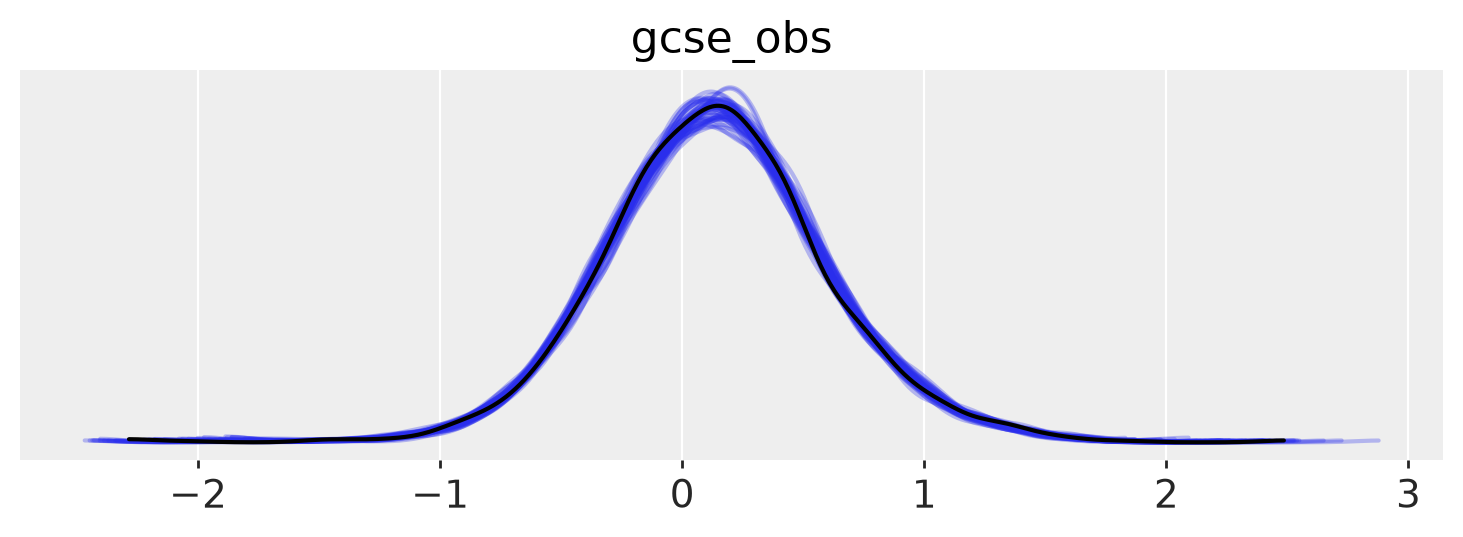

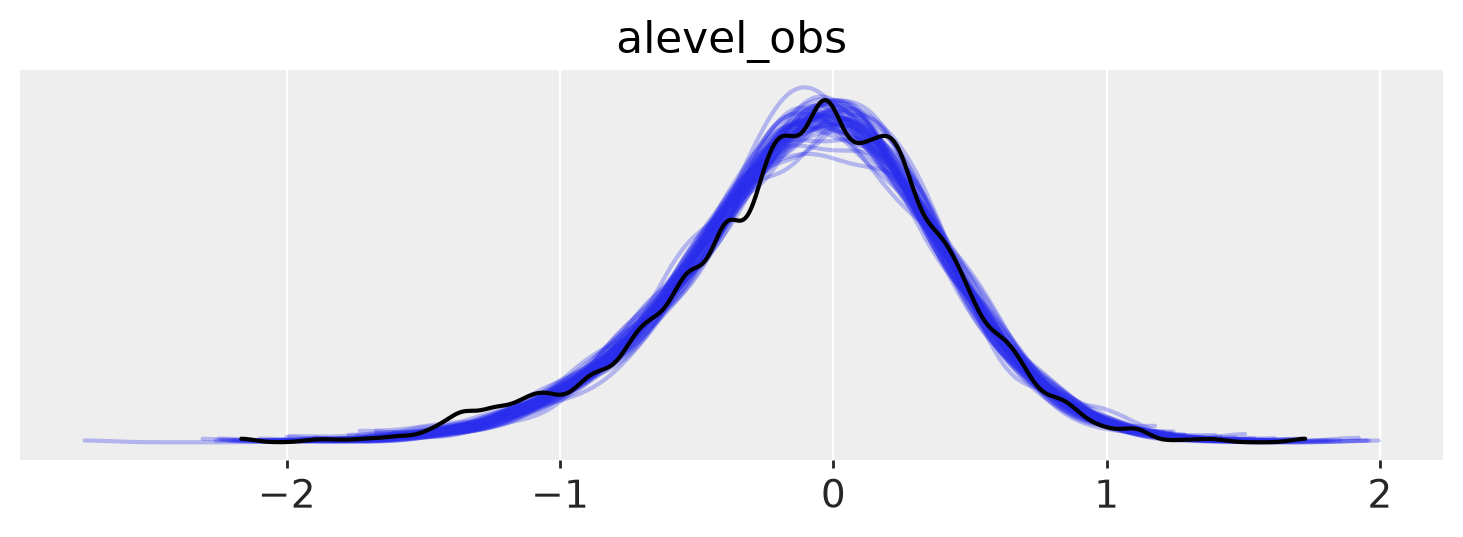

In [10]:
az.plot_ppc_dist(idata, var_names=["gcse_obs"])
plt.show()

az.plot_ppc_dist(idata, var_names=["alevel_obs"])
plt.show()

## Interpretation

`beta` is the estimated slope relating true GCSE maths value-added to true A-level maths value-added, after accounting for measurement error in both. Its posterior tells us whether — and how strongly — the two are related, without the noise in each measure attenuating the estimate the way a naive regression on the raw point estimates would.

## Next steps

- **Generalise across subjects**: reshape the wide A-level VA columns in `a-level-gcse-value-add.csv` to long format (school × subject), and extend this model to a hierarchical structure where `alpha`/`beta` are drawn per-subject from shared population distributions with partial pooling. That tells us whether GCSE-to-A-level carryover is a general phenomenon or specific to maths — subjects with few schools/small cohorts borrow strength from the population estimate rather than being fit in isolation.
- **Compare to a naive regression** on the point estimates only (no measurement-error model), to quantify how much attenuation the naive approach would have introduced.
- Only 1,622 of the 2,577 schools in `maths-value-add-errors.csv` have both a GCSE and A-level maths VA score recorded; worth checking whether that subset is representative (e.g. by school type or size) before over-generalising the conclusion.